# 07 — Ground-Truth Validation

**Goal:** hold the weak proxy against a **real labeled fake-review dataset** (Hollenbeck et al., MIT; 381,734 labeled reviews). Re-run the classifier on the real `is_fake` label through the *identical* pipeline; compare to the proxy; ask which signals survive.

> **Weak-proxy caveat.** Label = Amazon *Verified Purchase* (purchase verification, **not** ground-truth deception). Strengthened with behavioral signals; validated against real fake-review labels in notebook 07.

> **Label-circularity caveat.** The `primary` rule defines fake as a *5-star* review of a fake product by a fake reviewer, so `rating` is predictive *by construction*. The `labeled` strategy (human reviewer labels, rating-independent) is the honest test.

In [1]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from src import utils, viz
config = utils.load_config()
utils.set_seeds(config["project"]["random_seed"])
viz.set_house_style()
FIG = ROOT / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
cfg = utils.deep_merge(config, {"modeling": {"cv_folds": 3, "knn": {"n_neighbors_grid": [21]},
        "random_forest": {"n_estimators_grid": [200], "max_depth_grid": [None, 20]}}})

## 1. Real-label classifier (ground truth, `labeled` strategy)

2026-06-09 02:57:47,965 | review_deception.groundtruth | INFO | Loaded 12000 ground-truth reviews (strategy='labeled', fake rate=0.277)


2026-06-09 02:57:48,098 | review_deception.clean | INFO | Cleaned 12000 reviews (2 flagged exact-duplicate).


GT rows: 12000 | fake rate: 0.277


2026-06-09 02:57:51,813 | review_deception.features | INFO | Built feature table: 12000 rows × 45 columns.


2026-06-09 02:57:53,330 | review_deception.models | INFO | knn: CV roc_auc=0.695, test ROC-AUC=0.706


2026-06-09 02:57:58,574 | review_deception.models | INFO | random_forest: CV roc_auc=0.750, test ROC-AUC=0.772


{'knn': 0.706, 'random_forest': 0.772}


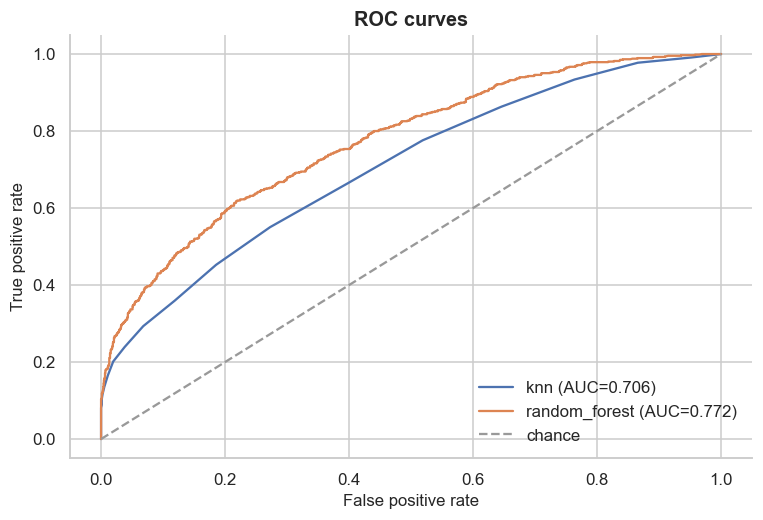

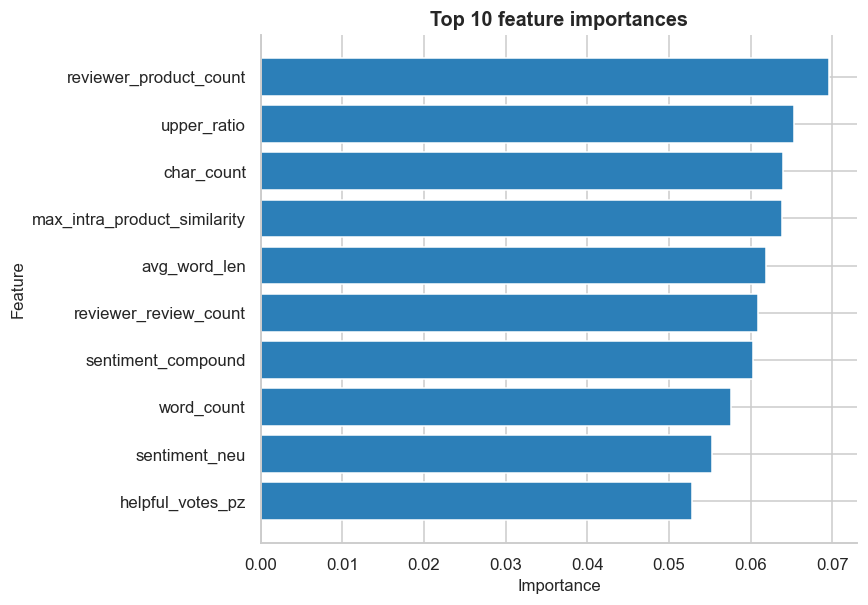

In [2]:
from src import groundtruth_loader as gtl, clean, models, features
gt = clean.clean_reviews(gtl.load_groundtruth(config, strategy="labeled", sample_rows=12000))
print("GT rows:", len(gt), "| fake rate:", round(gt["is_fake"].mean(), 3))
real = models.run_classification(gt, cfg, label_col="is_fake")
print({k: round(v["roc_auc"], 3) for k, v in real["results"].items()})
ax = viz.plot_roc_curves(real["results"]); viz.savefig(ax, str(FIG/"07_real_roc.png")); plt.show()
ax = viz.plot_feature_importances(real["results"]["random_forest"]["importances"], top=10)
viz.savefig(ax, str(FIG/"07_real_importances.png")); plt.show()

### How the story changes across label strategies

In [3]:
for strat in ["primary", "primary_or_deleted", "labeled"]:
    g = clean.clean_reviews(gtl.load_groundtruth(config, strategy=strat, sample_rows=8000))
    r = models.run_classification(g, cfg, label_col="is_fake")
    aucs = {k: round(v["roc_auc"], 3) for k, v in r["results"].items()}
    print(strat, "fake_rate", round(g["is_fake"].mean(), 3), aucs)

2026-06-09 02:58:00,815 | review_deception.groundtruth | INFO | Loaded 8000 ground-truth reviews (strategy='primary', fake rate=0.136)


2026-06-09 02:58:00,907 | review_deception.clean | INFO | Cleaned 8000 reviews (0 flagged exact-duplicate).


2026-06-09 02:58:03,566 | review_deception.features | INFO | Built feature table: 8000 rows × 45 columns.


2026-06-09 02:58:03,696 | review_deception.models | INFO | knn: CV roc_auc=0.979, test ROC-AUC=0.984


2026-06-09 02:58:06,133 | review_deception.models | INFO | random_forest: CV roc_auc=0.990, test ROC-AUC=0.990


...

2026-06-09 02:58:16,320 | review_deception.clean | INFO | Cleaned 8000 reviews (0 flagged exact-duplicate).


2026-06-09 02:58:19,311 | review_deception.features | INFO | Built feature table: 8000 rows × 45 columns.


2026-06-09 02:58:19,483 | review_deception.models | INFO | knn: CV roc_auc=0.680, test ROC-AUC=0.674


2026-06-09 02:58:22,429 | review_deception.models | INFO | random_forest: CV roc_auc=0.723, test ROC-AUC=0.722


labeled fake_rate 0.276 {'knn': 0.674, 'random_forest': 0.722}


## 2. Proxy-label classifier on the REAL Amazon data

2026-06-09 02:58:22,605 | review_deception.fallback | INFO | Loaded 16216 reviews for category 'Subscription_Boxes' from Subscription_Boxes.jsonl.gz


2026-06-09 02:58:22,780 | review_deception.clean | INFO | Cleaned 16216 reviews (447 flagged exact-duplicate).


2026-06-09 02:58:27,095 | review_deception.features | INFO | Built feature table: 16216 rows × 44 columns.


2026-06-09 02:58:27,451 | review_deception.models | INFO | knn: CV roc_auc=0.729, test ROC-AUC=0.731


2026-06-09 02:58:32,440 | review_deception.models | INFO | random_forest: CV roc_auc=0.789, test ROC-AUC=0.800


{'knn': 0.731, 'random_forest': 0.8}


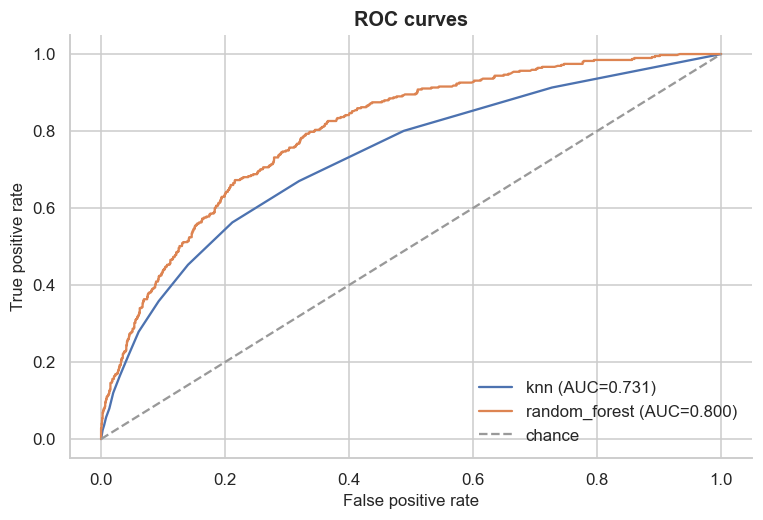

In [4]:
from src import fallback_loader as fl
raw = ROOT / "data" / "raw"
cats = sorted({p.name[:-9] for p in raw.glob("*.jsonl.gz") if not p.name.startswith("meta_")})
proxy_df = clean.clean_reviews(pd.concat([pd.DataFrame(fl.load_category(config, c, raw_dir=str(raw))) for c in cats], ignore_index=True))
proxy = models.run_classification(proxy_df, cfg)
print({k: round(v["roc_auc"], 3) for k, v in proxy["results"].items()})
ax = viz.plot_roc_curves(proxy["results"]); viz.savefig(ax, str(FIG/"07_proxy_roc.png")); plt.show()

## 3. Which signals survive? (per-feature AUC: real vs proxy)
High on both = robust; high on proxy only = artifact; high on real only = the proxy misses it.

In [5]:
real_auc = models.univariate_feature_auc(models.design_matrix(features.build_feature_table(gt, config)), gt["is_fake"])
proxy_auc = models.univariate_feature_auc(models.design_matrix(features.build_feature_table(proxy_df, config)), (proxy_df["verified_purchase"]==False).astype(int))
comp = pd.DataFrame({"proxy_auc": proxy_auc, "real_auc": real_auc}).fillna(0.5)
hi = 0.58
def verdict(r):
    if r.real_auc>=hi and r.proxy_auc>=hi: return "survives (both)"
    if r.proxy_auc>=hi: return "proxy-only (misleading)"
    if r.real_auc>=hi: return "real-only (proxy misses)"
    return "weak"
comp["verdict"] = comp.apply(verdict, axis=1)
print(comp.sort_values("proxy_auc", ascending=False).round(3).head(12).to_string())

2026-06-09 02:58:37,287 | review_deception.features | INFO | Built feature table: 12000 rows × 45 columns.


2026-06-09 02:58:41,272 | review_deception.features | INFO | Built feature table: 16216 rows × 44 columns.


                      proxy_auc  real_auc                  verdict
char_count                0.690     0.584          survives (both)
word_count                0.686     0.586          survives (both)
helpful_votes             0.601     0.521  proxy-only (misleading)
helpful_votes_pz          0.584     0.526  proxy-only (misleading)
sentiment_neg             0.581     0.510  proxy-only (misleading)
rating                    0.570     0.555                     weak
reviewer_mean_rating      0.569     0.545                     weak
exclaim_count             0.567     0.517                     weak
sentiment_pos             0.566     0.510                     weak
sentiment_neu             0.558     0.511                     weak
digit_ratio               0.556     0.504                     weak
product_rating_skew       0.556     0.516                     weak


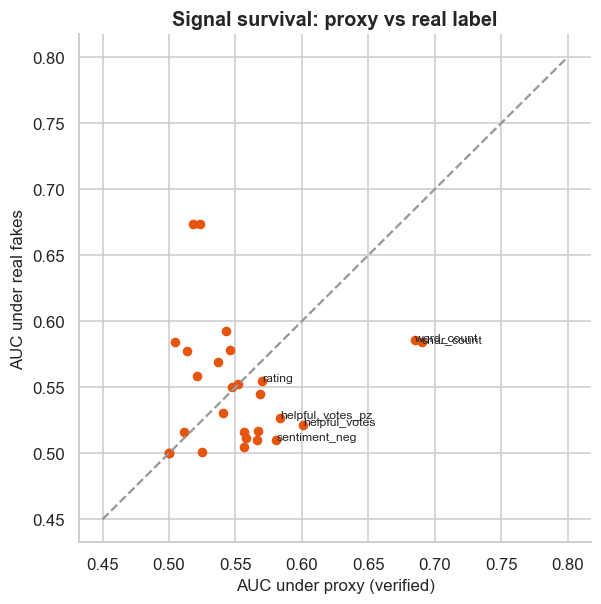

In [6]:
fig, axx = plt.subplots(figsize=(6,6))
axx.scatter(comp["proxy_auc"], comp["real_auc"], s=28, color=viz.TRUST_COLORS["unverified"])
lim=[0.45, max(0.8, float(comp[["proxy_auc","real_auc"]].max().max()))]; axx.plot(lim, lim, "--", color="#999")
for f in comp.sort_values("proxy_auc", ascending=False).head(6).index:
    axx.annotate(f, (comp.loc[f,"proxy_auc"], comp.loc[f,"real_auc"]), fontsize=8)
viz.label_axes(axx, "Signal survival: proxy vs real label", "AUC under proxy (verified)", "AUC under real fakes")
viz.savefig(axx, str(FIG/"07_survival.png")); plt.show()

## 4. Blind spots — honest write-up
From the table/scatter above, fill in for the poster:
- **Survives both** (robust deception signals): …
- **Proxy-only (misleading)** — predict verified-purchase but not real fakes: …
- **Real-only** — real-fake signals the verified flag misses: …
- **Rating-circularity lesson:** a label partly defined by a feature inflates that feature — exactly why ground-truth validation matters.
- **Bottom line:** the verified-purchase proxy is useful but imperfect; state plainly where it would mislead a platform that trusted it.